In [1]:
!pip install --upgrade protobuf tensorflow-datasets tensorflow-metadata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 7.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.2 which is incompatible.


In [2]:
!pip install -q importlib_resources

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
import tensorflow_datasets as tfds

In [4]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# project path
PROJECT_PATH = "/content/drive/MyDrive/project-01-transfer-learning"
os.chdir(PROJECT_PATH)

print("Current Directory: ", os.getcwd())

Current Directory:  /content/drive/MyDrive/project-01-transfer-learning


In [6]:
# Load oxford-iiit-pet dataset
ds_all, ds_info = tfds.load("oxford_iiit_pet",
                             split=["train", "test"],
                             as_supervised=True,
                             with_info=True
                             )

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.42VMG5_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.42VMG5_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.


In [7]:
class_names = ds_info.features['label'].names
print(f"Total Images: {ds_info.splits['train'].num_examples + ds_info.splits['test'].num_examples}")
print(f"Total Classes: {len(class_names)}")

Total Images: 7349
Total Classes: 37


In [8]:
class_names

['Abyssinian',
 'american_bulldog',
 'american_pit_bull_terrier',
 'basset_hound',
 'beagle',
 'Bengal',
 'Birman',
 'Bombay',
 'boxer',
 'British_Shorthair',
 'chihuahua',
 'Egyptian_Mau',
 'english_cocker_spaniel',
 'english_setter',
 'german_shorthaired',
 'great_pyrenees',
 'havanese',
 'japanese_chin',
 'keeshond',
 'leonberger',
 'Maine_Coon',
 'miniature_pinscher',
 'newfoundland',
 'Persian',
 'pomeranian',
 'pug',
 'Ragdoll',
 'Russian_Blue',
 'saint_bernard',
 'samoyed',
 'scottish_terrier',
 'shiba_inu',
 'Siamese',
 'Sphynx',
 'staffordshire_bull_terrier',
 'wheaten_terrier',
 'yorkshire_terrier']

In [9]:
train_ds, test_ds = ds_all
num_train_images = tf.data.experimental.cardinality(train_ds).numpy()
num_test_images = tf.data.experimental.cardinality(test_ds).numpy()
print(f"Number of training images: {num_train_images}")
print(f"Number of testing images: {num_test_images}")


Number of training images: 3680
Number of testing images: 3669


In [11]:
train_ds.element_spec

(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

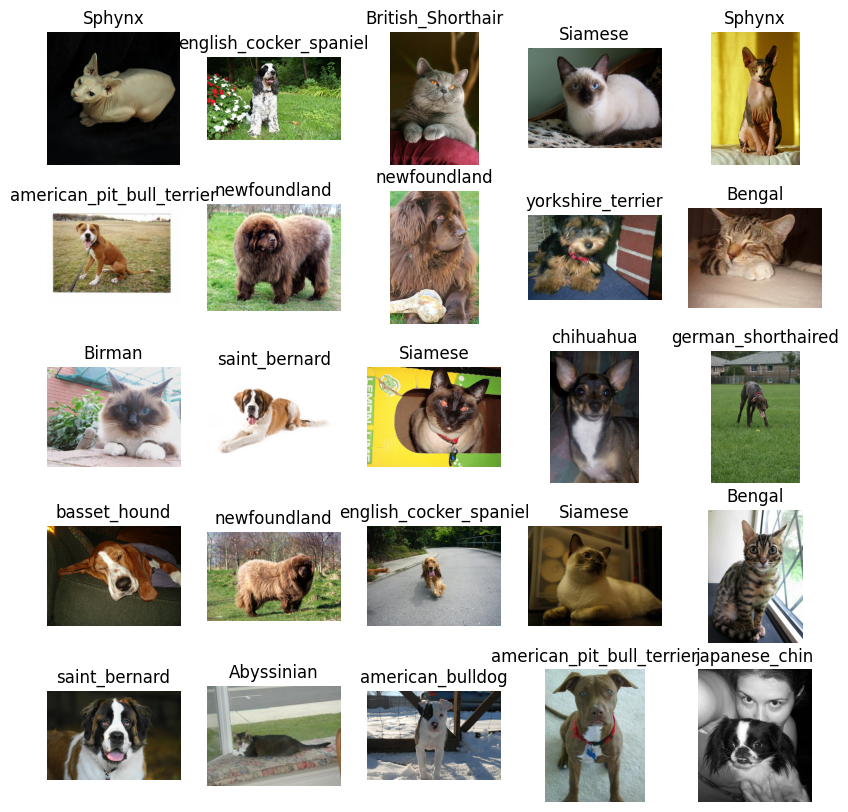

In [13]:
# plot 10 images
plt.figure(figsize=(10, 10))

for i, data in enumerate(train_ds.take(25)):
    plt.subplot(5, 5, i + 1)
    plt.imshow(data[0])
    plt.title(class_names[data[1]])
    plt.axis("off")


In [25]:
list_train_data = list(train_ds.as_numpy_iterator())
list_test_data = list(test_ds.as_numpy_iterator())

list_train_images = [data[0] for data in list_train_data]
list_train_labels = [data[1] for data in list_train_data]

list_test_images = [data[0] for data in list_test_data]
list_test_labels = [data[1] for data in list_test_data]

list_images = list_train_images + list_test_images
list_labels = list_train_labels + list_test_labels

print(f"Total Images: {len(list_images)}")
print(f"Total Labels: {len(list_labels)}")

Total Images: 7349
Total Labels: 7349


In [28]:
from pyarrow import list_
list_label_name = [class_names[label] for label in list_labels]
list_label_name[:10]

list_cats = [name for name in list_label_name if str(name)[0].isupper()]
list_dogs = [name for name in list_label_name if str(name)[0].islower()]

print(f"Total Cats: {len(list_cats)}")
print(f"Total Dogs: {len(list_dogs)}")

Total Cats: 2371
Total Dogs: 4978


In [31]:
unique_cats_name, cats_counts = np.unique(list_cats, return_counts=True)
unique_dogs_name, dogs_counts = np.unique(list_dogs, return_counts=True)

for name, count in zip(unique_cats_name, cats_counts):
    print(f"{name}: {count}")
print("-"*30)
for name, count in zip(unique_dogs_name, dogs_counts):
    print(f"{name}: {count}")

Abyssinian: 198
Bengal: 200
Birman: 200
Bombay: 184
British_Shorthair: 200
Egyptian_Mau: 190
Maine_Coon: 200
Persian: 200
Ragdoll: 200
Russian_Blue: 200
Siamese: 199
Sphynx: 200
------------------------------
american_bulldog: 200
american_pit_bull_terrier: 200
basset_hound: 200
beagle: 200
boxer: 199
chihuahua: 200
english_cocker_spaniel: 196
english_setter: 200
german_shorthaired: 200
great_pyrenees: 200
havanese: 200
japanese_chin: 200
keeshond: 199
leonberger: 200
miniature_pinscher: 200
newfoundland: 196
pomeranian: 200
pug: 200
saint_bernard: 200
samoyed: 200
scottish_terrier: 199
shiba_inu: 200
staffordshire_bull_terrier: 189
wheaten_terrier: 200
yorkshire_terrier: 200
